<a href="https://colab.research.google.com/github/islam2abdelhamid/AI-Engineer-Core-Track/blob/main/token_visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)



config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

### Token Prediction Visualizer
This section defines a function to predict and visualize the next possible tokens and their probabilities.

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import torch
import math
from typing import List, Dict

class QwenTokenPredictor:
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer

    def predict_tokens(self, prompt: str, max_new_tokens: int = 15, top_k_alts: int = 2) -> List[Dict]:
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.model.device)
        input_ids = inputs["input_ids"]

        predictions = []

        for _ in range(max_new_tokens):
            with torch.no_grad():
                outputs = self.model(input_ids)
                logits = outputs.logits[0, -1, :]
                probs = torch.nn.functional.softmax(logits, dim=-1)

                # Get top candidate and its probability
                top_prob, top_id = torch.topk(probs, k=top_k_alts + 1)

                # The actual token chosen (greedy)
                chosen_id = top_id[0].item()
                chosen_token = self.tokenizer.decode([chosen_id])

                if chosen_id == self.tokenizer.eos_token_id:
                    break

                # Get alternatives
                alternatives = []
                for i in range(1, top_k_alts + 1):
                    alt_id = top_id[i].item()
                    alt_token = self.tokenizer.decode([alt_id])
                    alt_prob = top_prob[i].item()
                    alternatives.append((alt_token, alt_prob))

                predictions.append({
                    "token": chosen_token,
                    "probability": top_prob[0].item(),
                    "alternatives": alternatives
                })

                # Update input_ids for next iteration
                input_ids = torch.cat([input_ids, torch.tensor([[chosen_id]], device=self.model.device)], dim=-1)

        return predictions

def create_qwen_token_graph(model_name: str, predictions: List[Dict]) -> nx.DiGraph:
    G = nx.DiGraph()
    G.add_node("START", token=model_name.split('/')[-1], prob="START", color="lightgreen", size=4000)

    for i, pred in enumerate(predictions):
        token_id = f"t{i}"
        G.add_node(token_id, token=pred["token"], prob=f"{pred['probability'] * 100:.1f}%", color="lightblue", size=6000)

        if i == 0:
            G.add_edge("START", token_id)
        else:
            G.add_edge(f"t{i - 1}", token_id)

        for j, (alt_token, alt_prob) in enumerate(pred["alternatives"]):
            alt_id = f"t{i}_alt{j}"
            G.add_node(alt_id, token=alt_token, prob=f"{alt_prob * 100:.1f}%", color="lightgray", size=6000)
            parent_node = "START" if i == 0 else f"t{i - 1}"
            G.add_edge(parent_node, alt_id)

    return G

def visualize_qwen_predictions(G: nx.DiGraph, figsize=(12, 12)):
    plt.figure(figsize=figsize)
    pos = {}
    spacing_y = 5
    spacing_x = 6

    main_nodes = [n for n in G.nodes() if "_alt" not in n]
    for i, node in enumerate(main_nodes):
        pos[node] = (0, -i * spacing_y)

    for node in G.nodes():
        if "_alt" in node:
            main_token_prefix = node.split("_")[0]
            alt_num = int(node.split("alt")[1])
            if main_token_prefix in pos:
                x_offset = -spacing_x if alt_num == 0 else spacing_x
                # Align alternative with the specific token step it belongs to
                pos[node] = (x_offset, pos[main_token_prefix][1])

    node_colors = [G.nodes[node]["color"] for node in G.nodes()]
    node_sizes = [G.nodes[node]["size"] for node in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes)
    nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True, arrowsize=20, alpha=0.5)

    labels = {node: f"{G.nodes[node]['token']}\n{G.nodes[node]['prob']}" for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=10)

    plt.title("Qwen Token Prediction Flow")
    plt.axis("off")
    plt.show()

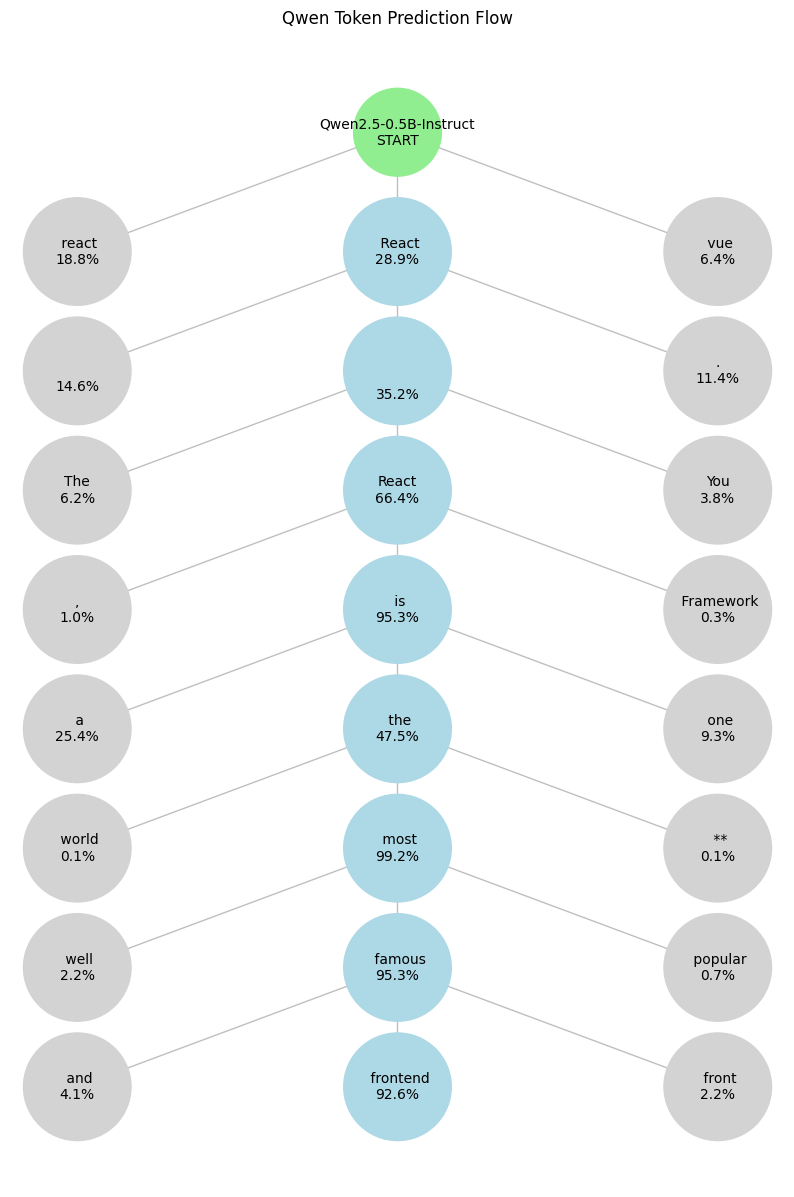

In [7]:
predictor = QwenTokenPredictor(model, tokenizer)
prompt = "in one word, what is the most famous frontend framework?"
predictions = predictor.predict_tokens(prompt, max_new_tokens=8)

G = create_qwen_token_graph(model_name, predictions)
visualize_qwen_predictions(G, figsize=(10, 15))